### Langchain Version 1

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain.agents import create_agent
os.environ["OPENROUTER_API_KEY"] = os.getenv("OPENROUTER_API_KEY")

d:\LangchainV2\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


In [ ]:
from langchain.chat_models import init_chat_model
model = init_chat_model(
    "nvidia/nemotron-3-super-120b-a12b:free",
    model_provider="openrouter"
)
model.invoke("what is the capital of india")

d:\LangchainV2\.venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


AIMessage(content='The capital of India is **New Delhi**.  \n\nIt is important to note that while "Delhi" often refers to the larger National Capital Territory (NCT) which includes both Old Delhi and New Delhi, the specific seat of the Indian government (including the President\'s residence, Parliament, and Supreme Court) is located in **New Delhi**. New Delhi was officially designated as the capital in 1911, replacing Calcutta (now Kolkata) during the British Raj, and it retained this status after India\'s independence in 1947.  \n\nFor clarity:  \n- **New Delhi** = The administrative capital (where government functions are centered).  \n- **Delhi** = The broader metropolitan area (a union territory) encompassing New Delhi, Old Delhi, and surrounding regions.  \n\nIf you have any follow-up questions about India\'s geography, history, or governance, feel free to ask! 😊', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the capital of India. That\'s a straightforwar

: 

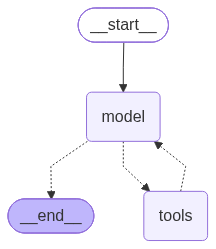

In [4]:
def get_weather(city:str)->str:
    """Get the weather for a city"""
    return f"The weather in {city} is sunny."


agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt="You are a helpful assistant."
)

agent

In [6]:
agent.invoke({"messages":[{"role":"user","content":"what is the weather in banglaore?"}]})

{'messages': [HumanMessage(content='what is the weather in banglaore?', additional_kwargs={}, response_metadata={}, id='23657437-be59-4c3e-9365-7a506a83e68c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking for the weather in "banglaore". That\'s likely a typo for "Bangalore". I should use the get_weather tool with city "Bangalore". Let me call it', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user is asking for the weather in "banglaore". That\'s likely a typo for "Bangalore". I should use the get_weather tool with city "Bangalore". Let me call it'}]}, response_metadata={'model_name': 'nvidia/nemotron-3-super-120b-a12b:free', 'id': 'gen-1787766371-4rbL6YAdFOXwNeeywhGg', 'created': 1787766371, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 0.0, 'upstream_inference_prompt

In [7]:
agent.invoke({"messages":"what is the weather in new york?"})

{'messages': [HumanMessage(content='what is the weather in new york?', additional_kwargs={}, response_metadata={}, id='27577d40-0274-4265-94c6-d940f5b9f22e'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to get the weather for New York. Use get_weather tool with city "New York".\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'We need to get the weather for New York. Use get_weather tool with city "New York".\n'}]}, response_metadata={'model_name': 'nvidia/nemotron-3-super-120b-a12b:free', 'id': 'gen-1787766380-Sy5WK3KCXvGB1jQE6K66', 'created': 1787766380, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 0.0, 'upstream_inference_prompt_cost': 0.0, 'upstream_inference_cost': 0.0}}, id='lc_run--01a03f2e-16af-7b00-a384-343dd8ab6dc4-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 

### Streaming and Batch

In [11]:
for chunk in model.stream("Write me 200 words paragraph on AI"):
    print(chunk.text, end="|", flush=True)

|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||Artificial Intelligence| (AI) refers| to the simulation of| human intelligence processes by| machines, particularly computer| systems, enabling them| to perform tasks that| typically require human cognition| such as learning|, reasoning, problem|-solving, perception|, and language| understanding. At its| core, AI lever|ages algorithms and vast| datasets to| identify patterns, make| predictions, and adapt| to| new information without explicit| programming for every| scenario. Key| subfields include| Machine Learning (ML|), where systems improve| through| experience;| Deep Learning,| utilizing| neural networks inspired by| the human brain for| complex pattern| recognition; Natural| Language Processing (N|LP), allowing| machines to interpret| and generate human language|; and Computer| Vision, enabling interpretation| of visual information| from|

In [12]:
model.batch(["Why do parrots have colourful weather?","How do airplane fly?","What is qunatum computing?"],config={
    "max_concurrency": 5, # limit to 5 parallel calls
})

[AIMessage(content='That\'s an interesting question, but it seems there might be a small mix-up in the wording! Parrots don\'t have "colourful **weather**" — weather refers to atmospheric conditions like rain, sun, or wind, which parrots don\'t *possess*. \n\nI suspect you meant to ask: **"Why do parrots have colourful *feathers*?"** This is a very common and excellent question about parrot biology! If that\'s what you intended, here\'s the answer:\n\n### Why Parrots Have Colourful Feathers:\nParrots evolve bright plumage (feathers) for several key reasons, all tied to survival and reproduction in their natural habitats (mostly tropical forests):\n\n1. **Camouflage in Vibrant Environments**:  \n   Tropical rainforests are bursting with color — flowers, fruits, sunlight filtering through leaves. Bright greens, blues, yellows, and reds help parrots blend into this kaleidoscope of foliage when viewed from certain angles (e.g., a green parrot against leaves). Ironically, being bright can *